In [ ]:
import numpy as np
import pandas as pd
import os

# Mostrar datasets disponibles
print("Datasets cargados:")
print(os.listdir('/kaggle/input'))

# Cambia el nombre cuando veas el resultado anterior
BASE = "/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification"

TRAIN_PATH = BASE + "/train"
VAL_PATH   = BASE + "/valid"
TEST_PATH  = BASE + "/test"

print("Train:", TRAIN_PATH)
print("Valid:", VAL_PATH)
print("Test :", TEST_PATH)

In [ ]:
import os

BASE = "/kaggle/input/datasets/utkarshsaxenadn/fruits-classification"

print("Contenido de BASE:")
print(os.listdir(BASE))

##  1. CONFIGURACIÓN DEL DISPOSITIVO
Usamos GPU si está disponible, ya que acelera enormemente el entrenamiento.
En Kaggle, si activas la GPU en la configuración del notebook, usará CUDA.

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

for dirname, dirnames, filenames in os.walk('/kaggle/input'):
    print(dirname)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/utkarshsaxenadn
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/valid
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/valid/Apple
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/valid/Strawberry
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/valid/Grape
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/valid/Banana
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/valid/Mango
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/test
/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification/test/Apple
/kaggle/input/datasets/utkar

In [4]:
# Importación de librerías
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Rutas del dataset
BASE = "/kaggle/input/datasets/utkarshsaxenadn/fruits-classification/Fruits Classification"

TRAIN_PATH = BASE + "/train"
VAL_PATH   = BASE + "/valid"
TEST_PATH  = BASE + "/test"

# Preprocesado de imágenes
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Carga de los conjuntos de entrenamiento, validación y prueba
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transform)
val_dataset   = datasets.ImageFolder(VAL_PATH, transform=transform)
test_dataset  = datasets.ImageFolder(TEST_PATH, transform=transform)

# Información básica del dataset
print("Clases:", train_dataset.classes)
print("Número de clases:", len(train_dataset.classes))

Clases: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Número de clases: 5


# 5. DATA LOADERS
 Los DataLoaders se encargan de:
   - Cargar imágenes en lotes (batch_size=64) para procesar en paralelo.
   - Barajar los datos de entrenamiento (shuffle=True) en cada época,
     lo que evita que el modelo aprenda el orden de los datos.
   - Validación y test NO se barajan: el orden no importa en evaluación.

In [6]:
# Creación de los DataLoaders.
# Se mezclan únicamente los datos de entrenamiento para mejorar la generalización.
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 6. VISUALIZACIÓN DE ALGUNAS IMÁGENES
 Mostramos 5 imágenes del primer batch para verificar que los datos
 se están cargando y etiquetando correctamente.

In [7]:
# Comprobación del formato de los datos cargados.
# Se espera un batch de tamaño [64, 3, 224, 224] y un vector de etiquetas de longitud 64.
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


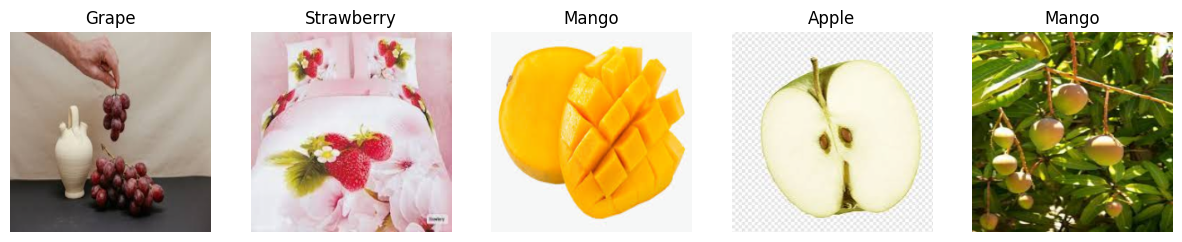

In [8]:
# Valores utilizados para desnormalizar las imágenes
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Obtención de un batch del conjunto de entrenamiento
images, labels = next(iter(train_loader))

# Creación de una figura para mostrar 5 imágenes
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i in range(5):

    # Conversión del tensor al formato esperado por matplotlib
    img = images[i].permute(1, 2, 0).numpy()

    # Desnormalización de la imagen
    img = std * img + mean

    # Ajuste de valores al rango válido
    img = np.clip(img, 0, 1)

    # Visualización de la imagen
    axes[i].imshow(img)

    # Mostrar la clase correspondiente
    axes[i].set_title(train_dataset.classes[labels[i]])

    # Ocultar ejes para una mejor visualización
    axes[i].axis("off")

# Mostrar la figura
plt.show()

# 7. DEFINICIÓN DEL MODELO — TRANSFER LEARNING CON ResNet-18
 Usamos Transfer Learning: partimos de un modelo ResNet-18 preentrenado en ImageNet (más de 1 millón de imágenes, 1000 clases).
 
 Las capas convolucionales ya saben extraer características visuales generales (bordes, texturas, formas), por lo que solo necesitamos adaptar la última capa.

In [9]:
# Carga de la arquitectura ResNet18 preentrenada
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# Selección de los pesos preentrenados en ImageNet
weights = ResNet18_Weights.DEFAULT

# Creación del modelo
model = resnet18(weights=weights)

# Activación del entrenamiento de todas las capas (fine tuning)
for param in model.parameters():
    param.requires_grad = False

# Número de clases del dataset
num_classes = len(train_dataset.classes)

# Sustitución de la capa final para adaptarla al problema
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

# Envío del modelo al dispositivo de ejecución
model = model.to(device)

# Comprobación de la capa de salida
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s] 

Linear(in_features=512, out_features=5, bias=True)


# 8. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
 CrossEntropyLoss: combina LogSoftmax + NLLLoss. Es la pérdida estándar
 para clasificación multiclase. Compara las probabilidades predichas
 con la clase real y penaliza las predicciones incorrectas.

In [10]:
# Función de pérdida utilizada para clasificación multiclase
criterion = nn.CrossEntropyLoss()

# Si se realiza fine tuning completo, deben optimizarse todos los parámetros:
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# Si se congelan las capas preentrenadas (feature extraction),
# solo se optimiza la capa final de clasificación.
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# 9. BUCLE DE ENTRENAMIENTO

In [11]:
# Número de Épocas (veces que la red ve el dataset completo)
epochs = 3

for epoch in range(epochs):

    model.train() # Pone la red en modo entrenamiento (activa Dropout)

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        # Enviamos los datos al dispositivo
        images = images.to(device)
        labels = labels.to(device)

        # Paso 1: Limpiamos los gradientes acumulados del paso anterior.
        #         Si no lo hacemos, los gradientes se suman y el entrenamiento diverge.
        optimizer.zero_grad()

        # Paso 2: Forward pass — el modelo hace sus predicciones.
        outputs = model(images)

        # Paso 3: Calculamos la pérdida entre predicciones y etiquetas reales.
        loss = criterion(outputs, labels)

        # Paso 4: Backward pass — calculamos los gradientes con backpropagation.
        loss.backward()

        # Paso 5: El optimizador actualiza los pesos según los gradientes.
        optimizer.step()

        # Acumulamos métricas para mostrar al final de la época
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}")

    print(f"Loss: {running_loss/len(train_loader):.4f}")

    print(f"Accuracy: {accuracy:.2f}%")

Epoch 1
Loss: 1.4154
Accuracy: 42.56%
Epoch 2
Loss: 1.0535
Accuracy: 68.28%
Epoch 3
Loss: 0.8585
Accuracy: 75.82%


# 10. EVALUACIÓN EN VALIDACIÓN
 Evaluamos el modelo en el conjunto de validación para estimar
 el rendimiento sobre datos no vistos durante el entrenamiento.

In [12]:
# Evaluación del modelo sobre el conjunto de validación

# Modo evaluación: desactiva comportamientos específicos del entrenamiento
model.eval()

# Variables para calcular la precisión
correct = 0
total = 0

# Desactiva el cálculo de gradientes para acelerar la inferencia
with torch.no_grad():

    # Recorrido del conjunto de validación
    for images, labels in val_loader:

        # Transferencia de datos al dispositivo
        images = images.to(device)
        labels = labels.to(device)

        # Obtención de las predicciones del modelo
        outputs = model(images)

        # Selección de la clase con mayor probabilidad
        _, predicted = torch.max(outputs, 1)

        # Actualización de métricas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Cálculo de la precisión final
val_accuracy = 100 * correct / total

print(
    f"Validation Accuracy: "
    f"{val_accuracy:.2f}%"
)

Validation Accuracy: 76.00%


# 11. EVALUACIÓN FINAL EN TEST
 El conjunto de test da la estimación final e imparcial del rendimiento.
 Solo debe consultarse UNA vez al final, tras fijar todos los hiperparámetros.

In [13]:
# Evaluación final del modelo sobre el conjunto de prueba

# Modo evaluación
model.eval()

# Variables para calcular la precisión
correct = 0
total = 0

# Desactiva el cálculo de gradientes durante la inferencia
with torch.no_grad():

    # Recorrido del conjunto de prueba
    for images, labels in test_loader:

        # Transferencia de datos al dispositivo
        images = images.to(device)
        labels = labels.to(device)

        # Obtención de las predicciones
        outputs = model(images)

        # Selección de la clase predicha
        _, predicted = torch.max(outputs, 1)

        # Actualización de métricas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Cálculo de la precisión sobre el conjunto de prueba
test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 81.00%


# 12. VISUALIZACIÓN FINAL DE PREDICCIONES
 Mostramos una cuadrícula 3x3 con imágenes y sus etiquetas reales
 para hacer una inspección visual rápida del dataset.

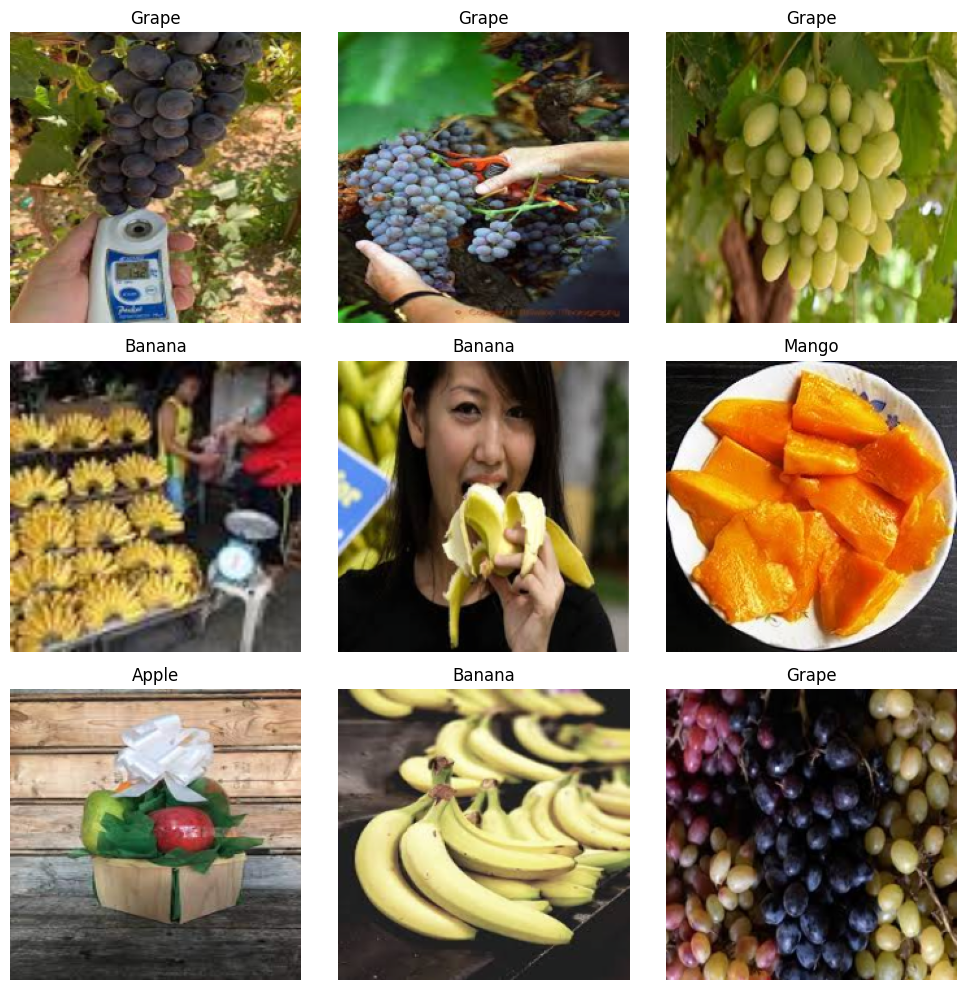

In [14]:
# Visualización de algunas imágenes del conjunto de entrenamiento

images, labels = next(iter(train_loader))

# Valores utilizados para desnormalizar las imágenes
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Creación de una cuadrícula 3x3
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i in range(9):

    # Conversión al formato esperado por matplotlib
    img = images[i].permute(1,2,0).numpy()

    # Desnormalización de la imagen
    img = std * img + mean
    img = np.clip(img, 0, 1)

    # Visualización de la imagen
    axes[i//3, i%3].imshow(img)

    # Mostrar la clase asociada
    axes[i//3, i%3].set_title(
        train_dataset.classes[labels[i]]
    )

    # Ocultar ejes
    axes[i//3, i%3].axis("off")

plt.tight_layout()
plt.show()

# 13. Evaluación y Métricas Avanzadas
Una CNN debería superar fácilmente el 98-99% de precisión en MNIST.


--- Reporte de Clasificación CNN ---
              precision    recall  f1-score   support

       Apple       0.68      0.65      0.67        20
      Banana       0.83      0.95      0.88        20
       Grape       1.00      0.80      0.89        20
       Mango       0.75      0.75      0.75        20
  Strawberry       0.82      0.90      0.86        20

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.81      0.81       100



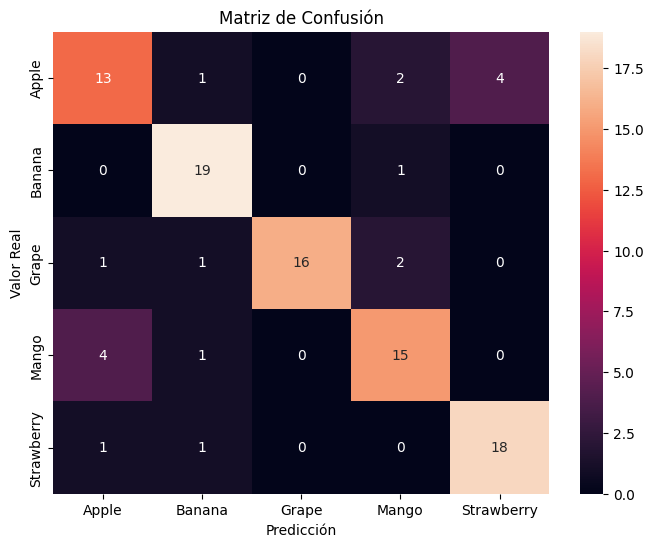

In [15]:
# Importación de métricas de evaluación y librerías de visualización
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluación del modelo sobre el conjunto de prueba
model.eval()

# Listas para almacenar etiquetas reales y predicciones
all_preds = []
all_labels = []

# Desactiva el cálculo de gradientes durante la inferencia
with torch.no_grad():

    # Recorrido del conjunto de prueba
    for inputs, labels in test_loader:

        # Transferencia de datos al dispositivo
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Obtención de las predicciones
        outputs = model(inputs)

        # Selección de la clase predicha
        _, predicted = torch.max(outputs, 1)

        # Almacenamiento de resultados para el cálculo de métricas
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Reporte de clasificación por clase
print("\n--- Reporte de Clasificación CNN ---")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

# Cálculo de la matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Representación gráfica de la matriz de confusión
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()